In [1]:
import os
import pandas as pd
import xarray as xr

# Dossiers où sont stockés les fichiers
data_dirs = {
    "Chlorophylle (mg/m³)": "./my_data_folder/chl_folder",
    "Température SST (°C)": "./my_data_folder/sst_folder",
    "Niveau de la mer (m)": "./my_data_folder/sea_level_folder"
}

# Initialiser un DataFrame vide
df_list = []

# Boucle sur chaque variable pour extraire les données
for var_name, directory in data_dirs.items():
    for file_name in os.listdir(directory):
        if file_name.endswith(".nc"):  # Vérifier que c'est un fichier NetCDF
            file_path = os.path.join(directory, file_name)
            ds = xr.open_dataset(file_path)
            
            # Extraction des variables : temps et valeur moyenne
            time_var = ds["time"].values  # Variable temps
            data_var = ds[list(ds.data_vars)[0]]  # Prendre la première variable

            # Si les données ont des dimensions spatiales, on fait la moyenne spatiale
            if "latitude" in data_var.dims and "longitude" in data_var.dims:
                data_mean = data_var.mean(dim=["latitude", "longitude"]).values
            else:
                data_mean = data_var.values  # Si pas de dimensions spatiales

            # Ajouter au DataFrame
            df_temp = pd.DataFrame({"Date": time_var, var_name: data_mean})
            df_list.append(df_temp)

# Fusionner les DataFrames
df_final = pd.concat(df_list, axis=0).sort_values("Date")
df_final = df_final.groupby("Date").mean().reset_index()

# Afficher le tableau final
print(df_final)

            Date  Chlorophylle (mg/m³)  Température SST (°C)  \
0     1982-01-15                   NaN             -0.228126   
1     1982-02-15                   NaN             -0.251763   
2     1982-03-15                   NaN             -0.639396   
3     1982-04-15                   NaN             -0.828476   
4     1982-05-15                   NaN             -1.347137   
...          ...                   ...                   ...   
11255 2023-10-15                   NaN              1.409275   
11256 2023-11-01              0.070774                   NaN   
11257 2023-11-15                   NaN              1.348947   
11258 2023-12-01              0.092599                   NaN   
11259 2023-12-15                   NaN              0.966553   

       Niveau de la mer (m)  
0                       NaN  
1                       NaN  
2                       NaN  
3                       NaN  
4                       NaN  
...                     ...  
11255                

            Date  Chlorophylle (mg/m³)  Température SST (°C)  \
0     1982-01-15                   NaN                -0.228   
1     1982-02-15                   NaN                -0.252   
2     1982-03-15                   NaN                -0.639   
3     1982-04-15                   NaN                -0.828   
4     1982-05-15                   NaN                -1.347   
...          ...                   ...                   ...   
11255 2023-10-15                   NaN                 1.409   
11256 2023-11-01                 0.071                   NaN   
11257 2023-11-15                   NaN                 1.349   
11258 2023-12-01                 0.093                   NaN   
11259 2023-12-15                   NaN                 0.967   

       Niveau de la mer (m)  
0                       NaN  
1                       NaN  
2                       NaN  
3                       NaN  
4                       NaN  
...                     ...  
11255                

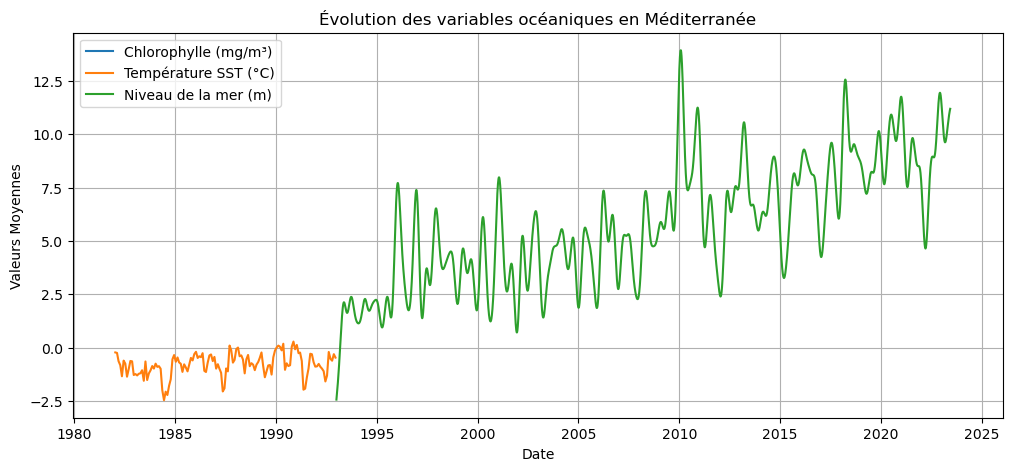

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurer l'affichage
pd.set_option("display.float_format", "{:.3f}".format)
print(df_final)

# Afficher une courbe pour chaque variable
plt.figure(figsize=(12, 5))
for col in df_final.columns[1:]:  # Ignorer la colonne "Date"
    plt.plot(df_final["Date"], df_final[col], label=col)

plt.xlabel("Date")
plt.ylabel("Valeurs Moyennes")
plt.title("Évolution des variables océaniques en Méditerranée")
plt.legend()
plt.grid()
plt.show()

In [4]:
import xarray as xr

# Charger un fichier et voir son contenu
file_path = "./my_data_folder/sst_folder/my_data_folder/sst_folder/sst_medsea_omi_tempsal_sst_area_averaged_monthly_anomalies_19820101-20231231_R19912020_P202405061.nc"  # Remplace par un vrai fichier
ds = xr.open_dataset(file_path)
print(ds)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/onyxia/work/Stat-App-Montee-des-oceans/my_data_folder/sst_folder/my_data_folder/sst_folder/sst_medsea_omi_tempsal_sst_area_averaged_monthly_anomalies_19820101-20231231_R19912020_P202405061.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)